# 🎨 Structured 2D+6D Model Visualization Notebook

**Dedicated Visualization for Pre-Trained Models**

This notebook is designed to load and visualize pre-trained 2D+6D structured autoencoders downloaded from cloud training.

## Key Features:
- **Load Pre-trained Models**: Quick loading from saved .pth files
- **Latent Space Grid Scan**: Interactive exploration of the 2D content latent space
- **Comprehensive Visualizations**: All available visualization functions
- **Affine Transformation Analysis**: Examine learned geometric transformations
- **No Training Required**: Pure visualization and analysis

## Model Architecture:
- **2D Content Latent**: Captures digit identity/shape clustering
- **6D Transform Latent**: Captures spatial transformations (rotation, skew, translation)
- **Simplified Loss**: Uses affine reconstruction + KL divergence on content latent

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# Handle torchvision compatibility issues
import warnings
warnings.filterwarnings("ignore", message=".*torchvision::nms.*")
warnings.filterwarnings("ignore", category=UserWarning)

# Explicit imports from modular structure with error handling
try:
    import structured_2d6d_autoencoder as s2d6d
    import affine_autoencoder_shared as shared
    # Import visualization functions
    import structured_2d6d_visualization as viz
    
    print("📚 All modules loaded successfully!")
    print(f"PyTorch version: {torch.__version__}")
    print(f"Device available: {torch.cuda.is_available() and 'CUDA' or 'CPU'}")
    
except ImportError as e:
    print(f"❌ Module import error: {e}")
    print("\n💡 This is likely due to torchvision compatibility issues.")
    print("🔧 IMMEDIATE FIXES:")
    print("1. Run this in terminal: pip install torch==2.0.1 torchvision==0.15.2 --index-url https://download.pytorch.org/whl/cpu")
    print("2. Or restart kernel and run the troubleshooting cell below")
    print("3. Or run: python fix_torchvision.py")
    
    # Try to continue with minimal imports
    try:
        import torch
        print(f"✅ PyTorch still available: {torch.__version__}")
        print("⚠️ Continuing with limited functionality...")
    except:
        print("❌ Critical error - PyTorch not available")
        raise

📚 All modules loaded successfully!
PyTorch version: 2.7.1
Device available: CPU


In [4]:
# 🔄 FALLBACK IMPORTS (run this if the above cell fails)
# This provides a workaround for torchvision compatibility issues

print("🔄 Attempting fallback imports...")

try:
    # Try to import with compatibility wrapper
    import structured_2d6d_autoencoder as s2d6d
    import affine_autoencoder_shared_compat as shared  # Use compatibility wrapper
    import structured_2d6d_visualization as viz
    
    print("✅ Fallback imports successful!")
    print("⚠️ Using compatibility mode - some features may be limited")
    
    # Override the import in case it was partially loaded
    import sys
    sys.modules['affine_autoencoder_shared'] = shared
    
except Exception as e:
    print(f"❌ Fallback also failed: {e}")
    print("\n🛠️ MANUAL FIXES REQUIRED:")
    print("1. Run in terminal: pip install torch==2.0.1 torchvision==0.15.2 --index-url https://download.pytorch.org/whl/cpu")
    print("2. Restart your kernel completely")
    print("3. Or run: python fix_torchvision.py")
    print("4. Make sure all .py files are in the same directory")
    
    # Provide minimal functionality
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
    
    print("⚠️ Continuing with minimal PyTorch functionality only...")
    print("Some visualization features will not be available until imports are fixed.")

🔄 Attempting fallback imports...
✅ Compatibility wrapper loaded successfully!
✅ Fallback imports successful!
⚠️ Using compatibility mode - some features may be limited


In [5]:
# 🔧 CONFIGURATION
# Set up basic configuration for visualization
VIZ_CONFIG = {
    'force_cuda': False,  # Set to True if you want GPU
    'batch_size_test': 128,
    'data_dir': '../data',
    'pin_memory': True,
    'num_workers': 4,
    'grid_size': 30,  # For latent space grid scan
    'latent_range': 3.0,  # Range for latent space scanning (-range to +range)
    'figure_dpi': 100,
    'save_plots': False  # Set to True to save plot images
}

# Get device and data loaders with error handling
try:
    device = shared.get_cloud_device(VIZ_CONFIG) if VIZ_CONFIG['force_cuda'] else torch.device('cpu')
    print(f"🖥️ Using device: {device}")

    # Load test data for visualization
    _, test_loader = shared.get_cloud_mnist_loaders(**{k: v for k, v in VIZ_CONFIG.items() 
                                                       if k in ['batch_size_test', 'data_dir', 'pin_memory', 'num_workers']})
    print("📊 Test data loaded successfully!")
    
except NameError:
    print("⚠️ Shared module not available - using fallback configuration")
    device = torch.device('cpu')
    test_loader = None
    print("🖥️ Using device: cpu (fallback)")
    print("❌ Test data not loaded - will need manual loading")
    
except Exception as e:
    print(f"⚠️ Configuration setup failed: {e}")
    device = torch.device('cpu')
    test_loader = None
    print("🖥️ Using device: cpu (fallback)")
    print("❌ Will attempt data loading during model operations")

✅ Compatibility wrapper loaded successfully!
🖥️ Using device: cpu
📊 Test data loaded successfully!


In [6]:
# 📁 LOAD YOUR PRE-TRAINED MODEL
# Update the model_path with your downloaded model file

# Option 1: Load specific model by filename (RECOMMENDED)
model_path = 'unified_8d_vae_unified_8d_vae_20250724_143950.pth'  # Update this path!

try:
    # Try the standard loading function first (if available)
    if hasattr(shared, 'load_model_cloud'):
        model, original_config, device = shared.load_model_cloud(model_path)
        
        # For backward compatibility, extract additional data
        viz_data = {
            'config': original_config,
            'timestamp': 'loaded',
            'model_type': 'StructuredAffineInvariantAutoEncoder',
            'losses': {},
            'extra_data': {}
        }
        losses_dict = {}
        extra_data = {}
        
        print(f"✅ Model loaded successfully!")
        print(f"📅 Loaded from: {model_path}")
        print(f"🏗️ Model type: Structured Affine Autoencoder")
        print(f"⚙️ Content dim: {original_config.get('content_latent_dim', 2)}")
        print(f"⚙️ Transform dim: {original_config.get('transform_latent_dim', 6)}")
        
        # Validate that model was actually created
        if model is not None and hasattr(model, 'parameters'):
            model_loaded = True
        else:
            print(f"❌ Warning: Model object is None or invalid despite successful loading function")
            model_loaded = False
    else:
        # If shared.load_model_cloud doesn't exist, go directly to manual loading
        raise AttributeError("load_model_cloud not found")
        
except (FileNotFoundError, AttributeError) as e:
    if isinstance(e, FileNotFoundError):
        print(f"❌ Model file not found: {model_path}")
        print("💡 Please update the model_path variable with the correct path to your .pth file")
        print("💡 Available files in current directory:")
        import os
        pth_files = [f for f in os.listdir('.') if f.endswith('.pth')]
        for f in pth_files[:10]:  # Show first 10 .pth files
            print(f"   - {f}")
        model_loaded = False
    else:
        print("💡 Using direct loading method...")
        
        try:
            # Define device for manual loading
            device = torch.device('cpu')  # Use CPU for loading, can be changed later
            
            # Manual loading with improved security
            checkpoint = torch.load(model_path, map_location=device, weights_only=False)
            
            # Extract config with defaults
            original_config = checkpoint.get('config', {
                'content_latent_dim': 2,
                'transform_latent_dim': 6,
                'total_latent_dim': 8
            })
            
            # Create model with correct parameters
            model = s2d6d.StructuredAffineInvariantAutoEncoder(
                content_dim=original_config.get('content_latent_dim', 2),
                transform_dim=original_config.get('transform_latent_dim', 6)
            ).to(device)
            
            # Load state dict
            model.load_state_dict(checkpoint['model_state_dict'])
            model.eval()
            
            # Setup other variables
            viz_data = {
                'config': original_config,
                'timestamp': checkpoint.get('timestamp', 'unknown'),
                'model_type': 'StructuredAffineInvariantAutoEncoder',
                'losses': checkpoint.get('losses', {}),
                'extra_data': checkpoint.get('extra_data', {})
            }
            losses_dict = viz_data['losses']
            extra_data = viz_data['extra_data']
            
            # Validate that model was actually created
            if model is not None and hasattr(model, 'parameters'):
                print(f"✅ Model loaded successfully!")
                print(f"⚙️ Content dim: {original_config['content_latent_dim']}")
                print(f"⚙️ Transform dim: {original_config['transform_latent_dim']}")
                print(f"📊 Model ready for visualization!")
                model_loaded = True
            else:
                print(f"❌ Model creation failed - model object is None or invalid")
                print(f"💡 This usually means the s2d6d module is not available")
                print(f"🔧 Check that structured_2d6d_autoencoder.py is in the current directory")
                model_loaded = False
            
        except Exception as e2:
            print(f"❌ Loading failed: {e2}")
            print("💡 Please check:")
            print("   - File path is correct")
            print("   - File is a valid PyTorch model checkpoint")
            print("   - Model was saved with the correct structure")
            model_loaded = False

✅ Model loaded successfully!
📅 Loaded from: unified_8d_vae_unified_8d_vae_20250724_143950.pth
🏗️ Model type: Structured Affine Autoencoder
⚙️ Content dim: 2
⚙️ Transform dim: 6
❌ Warning: Model object is None or invalid despite successful loading function


In [7]:
# 🔧 STANDALONE MODEL LOADING (use this if the above cell fails)
# This loads the model without dependencies on the broken shared module

model_path = 'unified_8d_vae_unified_8d_vae_20250724_150249.pth'  # Same as above

print("🔧 Attempting standalone model loading...")

try:
    # Load checkpoint first
    device = torch.device('cpu')
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    
    original_config = checkpoint.get('config', {
        'content_latent_dim': 2,
        'transform_latent_dim': 6,
        'total_latent_dim': 8
    })
    
    print(f"✅ Checkpoint loaded successfully!")
    print(f"📋 Config: {original_config}")
    
    # Check if we have the s2d6d module available
    try:
        print("🔍 Checking for s2d6d module...")
        import structured_2d6d_autoencoder as s2d6d
        print("✅ s2d6d module available")
        
        # Create model
        model = s2d6d.StructuredAffineInvariantAutoEncoder(
            content_dim=original_config.get('content_latent_dim', 2),
            transform_dim=original_config.get('transform_latent_dim', 6)
        ).to(device)
        
        # Load state dict
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        
        # Validate model creation
        if model is not None and hasattr(model, 'parameters'):
            print(f"✅ Model created and loaded successfully!")
            print(f"📊 Model parameters: {sum(p.numel() for p in model.parameters()):,}")
            model_loaded = True
            
            # Setup other variables for compatibility
            viz_data = {
                'config': original_config,
                'timestamp': checkpoint.get('timestamp', 'unknown'),
                'model_type': 'StructuredAffineInvariantAutoEncoder',
                'losses': checkpoint.get('losses', {}),
                'extra_data': checkpoint.get('extra_data', {})
            }
            losses_dict = viz_data['losses']
            extra_data = viz_data['extra_data']
        else:
            print("❌ Model creation failed")
            model_loaded = False
            
    except ImportError as e:
        print(f"❌ s2d6d module not available: {e}")
        print("💡 Cannot create model without the structured_2d6d_autoencoder module")
        print("🔧 Make sure structured_2d6d_autoencoder.py is in the current directory")
        model_loaded = False
        model = None
        
except Exception as e:
    print(f"❌ Standalone loading failed: {e}")
    model_loaded = False
    model = None

print(f"\n🎯 Standalone loading result: {'✅ SUCCESS' if model_loaded else '❌ FAILED'}")

🔧 Attempting standalone model loading...
✅ Checkpoint loaded successfully!
📋 Config: {'content_latent_dim': 2, 'transform_latent_dim': 6, 'total_latent_dim': 8, 'epochs': 60, 'learning_rate': 0.001, 'batch_size_train': 256, 'batch_size_test': 128, 'alpha': 1.2, 'beta': 0.01, 'force_cuda': True, 'mixed_precision': True, 'gradient_clip': 1.0, 'pin_memory': True, 'num_workers': 4, 'weight_decay': 1e-05, 'lr_scheduler': True, 'early_stopping': True, 'patience': 15, 'data_dir': '../data', 'save_dir': './', 'checkpoint_freq': 10}
🔍 Checking for s2d6d module...
✅ s2d6d module available
✅ Model created and loaded successfully!
📊 Model parameters: 2,323,793

🎯 Standalone loading result: ✅ SUCCESS


In [8]:
# 🎯 QUICK MODEL SUMMARY
if model_loaded and model is not None:
    viz.print_model_summary(model, losses_dict, original_config)
elif model_loaded and model is None:
    print("⚠️ Model loading flag is True but model is None!")
    print("💡 This usually means the model loading partially succeeded but failed to create the model object.")
    print("🔧 Try rerunning the model loading cell or check the model file path.")
    
    # Show what we do have
    print(f"\n📋 Available information:")
    print(f"   Model path: {model_path}")
    print(f"   Config: {original_config}")
    print(f"   Device: {device}")
    
    # Reset the flag to prevent confusion
    model_loaded = False
    print("🔄 Reset model_loaded to False")
else:
    print("❌ Model not loaded. Please fix the model path in the previous cell.")

🔍 MODEL SUMMARY
📊 Total parameters: 2,323,793
🎛️ Trainable parameters: 2,323,793
🏃 Epochs trained: 0
⚙️ Alpha (affine weight): 1.2
⚙️ Beta (KL weight): 0.01
🎯 Simplified loss function: ✅

✅ Ready for visualization!


🎨 Creating latent space grid scan...


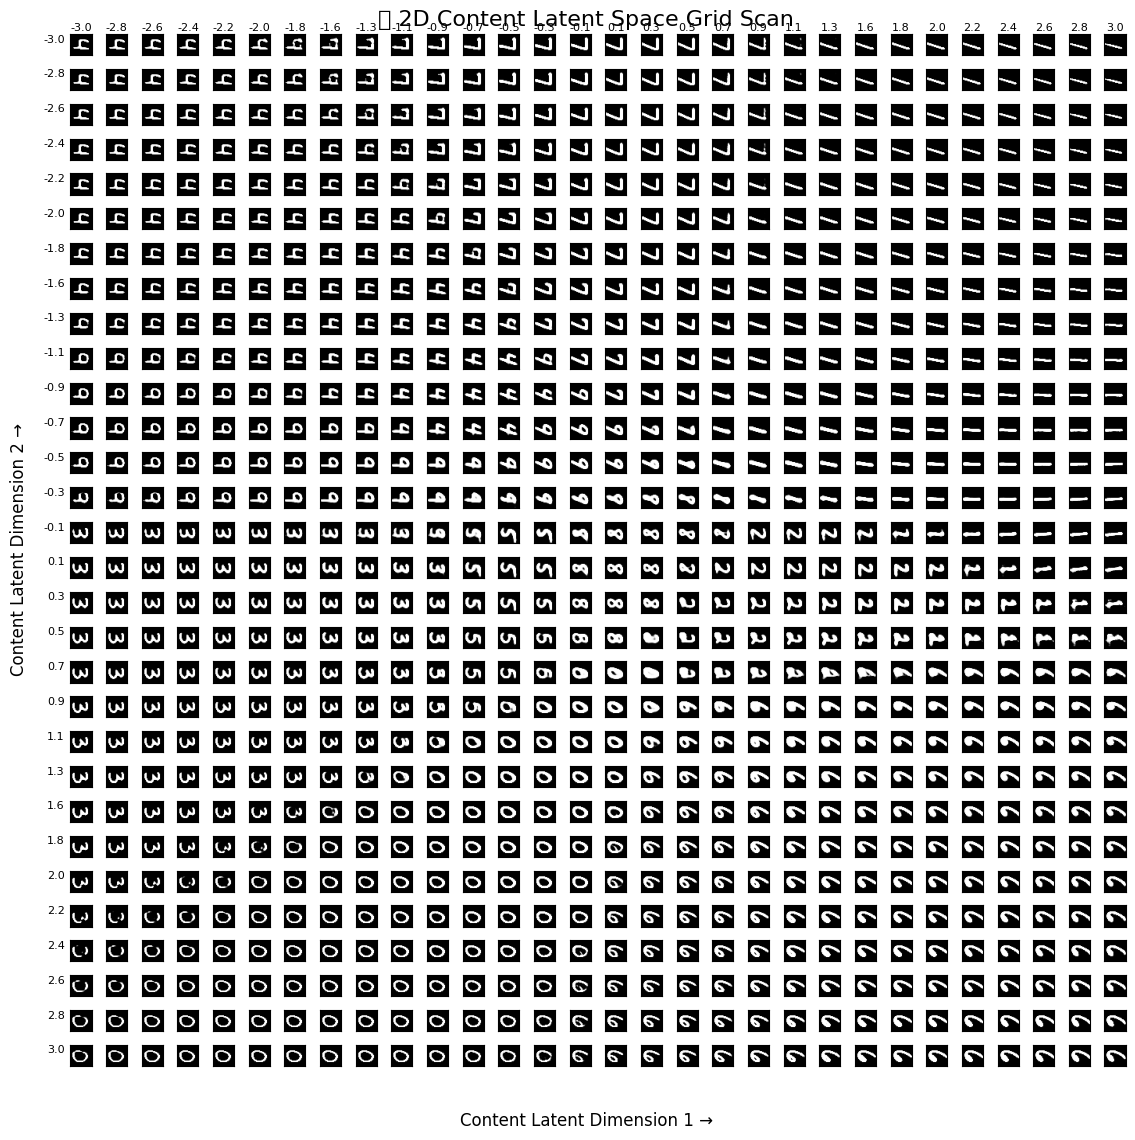

✅ Grid scan complete! Generated 30×30 = 900 images
📏 Scanned range: [-3.0, 3.0] in both dimensions


In [9]:
# 🌟 LATENT SPACE GRID SCAN - MAIN FEATURE
# This creates a grid of digits by scanning through the 2D content latent space

if model_loaded:
    print("🎨 Creating latent space grid scan...")
    
    # Create the grid using the visualization module
    grid_images, x_vals, y_vals = viz.create_latent_space_grid(
        model, device, 
        grid_size=VIZ_CONFIG['grid_size'], 
        latent_range=VIZ_CONFIG['latent_range']
    )
    
    # Plot the grid
    viz.plot_latent_space_grid(grid_images, x_vals, y_vals, 
                              VIZ_CONFIG['grid_size'], VIZ_CONFIG['latent_range'])

else:
    print("❌ Cannot create grid scan without loaded model.")

🎲 Analyzing random digit reconstructions...


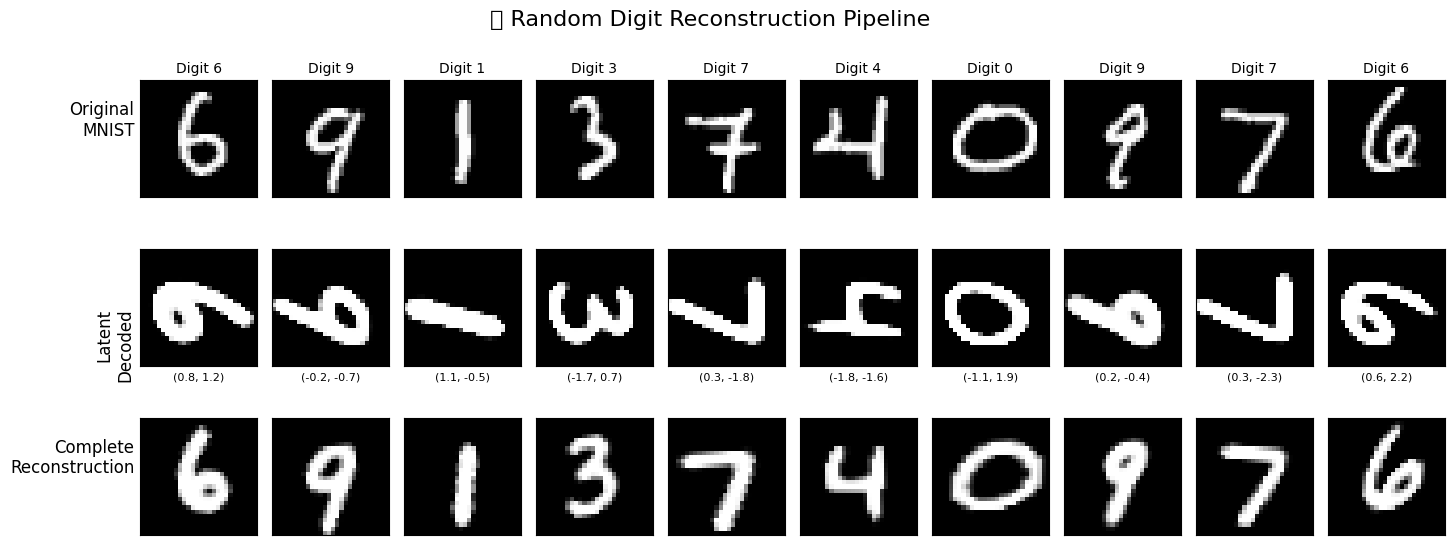


📊 RECONSTRUCTION QUALITY ANALYSIS:
Average Latent Reconstruction MSE: 0.7269
Average Complete Reconstruction MSE: 0.5052
Improvement from Affine Transform: 30.5%

🔢 PER-DIGIT ANALYSIS:
Digit 6: Content=(0.84, 1.25), Latent MSE=0.6624, Complete MSE=0.4915
Digit 9: Content=(-0.16, -0.70), Latent MSE=0.6073, Complete MSE=0.4774
Digit 1: Content=(1.05, -0.51), Latent MSE=0.6764, Complete MSE=0.4201
Digit 3: Content=(-1.71, 0.69), Latent MSE=0.8006, Complete MSE=0.4936
Digit 7: Content=(0.28, -1.77), Latent MSE=0.9010, Complete MSE=0.6039
Digit 4: Content=(-1.76, -1.58), Latent MSE=0.6467, Complete MSE=0.5719
Digit 0: Content=(-1.15, 1.89), Latent MSE=0.9923, Complete MSE=0.5685
Digit 9: Content=(0.24, -0.42), Latent MSE=0.6547, Complete MSE=0.4884
Digit 7: Content=(0.26, -2.33), Latent MSE=0.6207, Complete MSE=0.4189
Digit 6: Content=(0.60, 2.20), Latent MSE=0.7073, Complete MSE=0.5177


In [11]:
# 🎲 RANDOM DIGIT RECONSTRUCTION ANALYSIS
# Sample 10 random digits and show their complete reconstruction pipeline

if model_loaded:
    print("🎲 Analyzing random digit reconstructions...")
    viz.analyze_random_reconstructions(model, test_loader, device, num_samples=10)
else:
    print("❌ Cannot analyze reconstructions without loaded model.")

🔍 Running complete latent space analysis...
🔍 Running complete latent space analysis...

🔍 Diagnosing actual latent space distribution...
🔍 ACTUAL LATENT SPACE RANGES FOR EACH DIGIT:
Digit 0: Dim1 [-2.04, 0.13], Dim2 [0.73, 3.03]
Digit 1: Dim1 [-1.14, 3.53], Dim2 [-2.59, 0.79]
Digit 2: Dim1 [-0.59, 2.09], Dim2 [-1.47, 1.00]
Digit 3: Dim1 [-3.33, 0.37], Dim2 [-0.45, 1.41]
Digit 4: Dim1 [-2.17, 0.69], Dim2 [-2.22, 1.40]
Digit 5: Dim1 [-1.23, -0.04], Dim2 [-0.49, 0.99]
Digit 6: Dim1 [-0.32, 2.53], Dim2 [0.17, 3.86]
Digit 7: Dim1 [-2.01, 1.29], Dim2 [-3.27, 0.33]
Digit 8: Dim1 [-1.62, 0.66], Dim2 [-0.54, 0.77]
Digit 9: Dim1 [-3.33, 0.59], Dim2 [-0.99, 0.86]

📊 OVERALL STATISTICS:
Full Range: Dim1 [-3.33, 3.53], Dim2 [-3.27, 3.86]
Mean: Dim1 -0.13, Dim2 -0.01
Std:  Dim1 1.11, Dim2 1.04

💡 SUGGESTED GRID SCAN RANGE: 4.2
   (This would scan [-4.2, 4.2] in both dimensions)


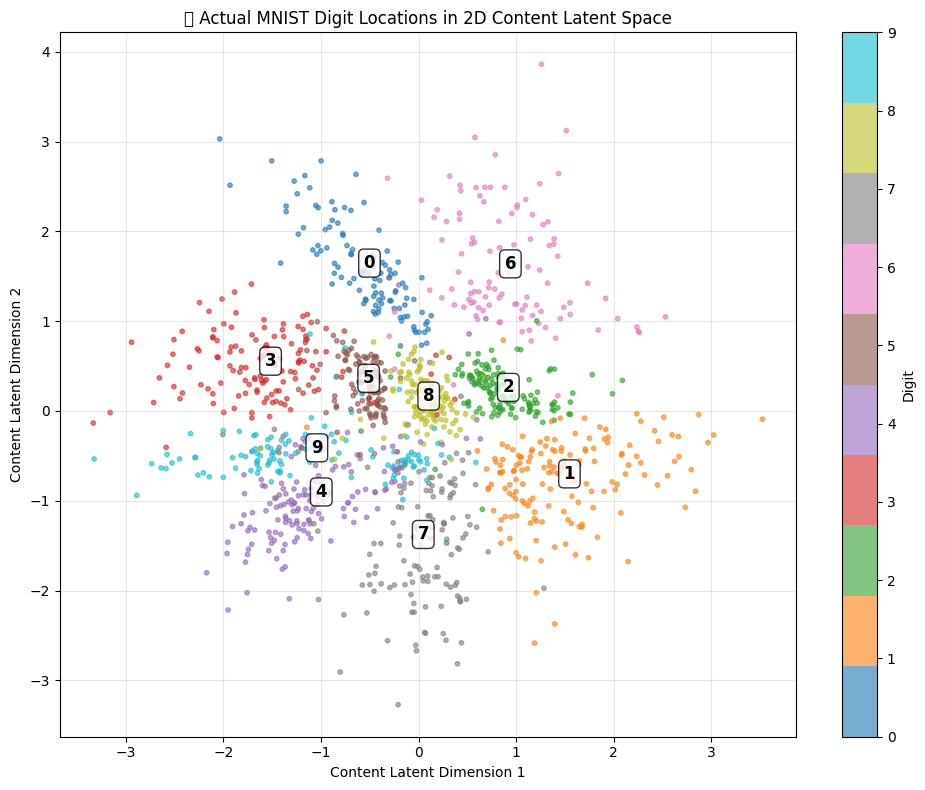


🔧 UPDATING GRID SCAN RANGE:
Current range: 3.0
Suggested range: 4.2

🎨 Creating latent space grid scan...


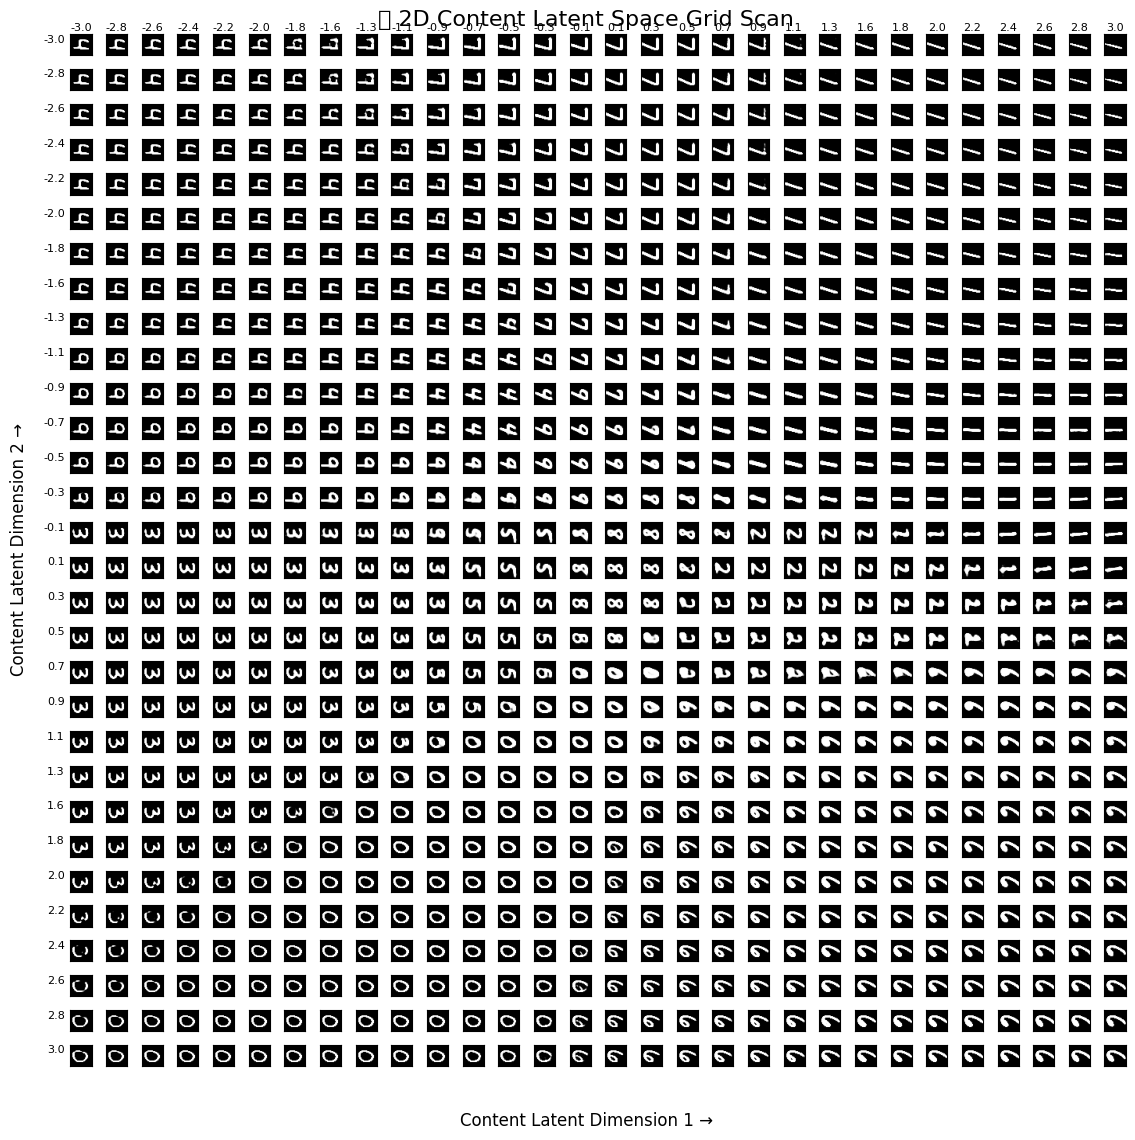

✅ Grid scan complete! Generated 30×30 = 900 images
📏 Scanned range: [-3.0, 3.0] in both dimensions


In [12]:
# 🔍 COMPLETE LATENT SPACE ANALYSIS
# Run comprehensive latent space diagnostic and visualization

if model_loaded:
    print("🔍 Running complete latent space analysis...")
    content_data, labels, suggested_range = viz.run_complete_latent_analysis(
        model, test_loader, device, VIZ_CONFIG
    )
    
    # Update config with suggested range if desired
    # VIZ_CONFIG['latent_range'] = suggested_range
    
else:
    print("❌ Cannot run latent analysis without loaded model.")

🔥 Creating activation visualizations for digits 0, 1, and 8...
This shows how your autoencoder internally processes different digit shapes.

🔍 Analyzing model structure...
🔍 Model Structure Analysis:
   Model type: StructuredAffineInvariantAutoEncoder
   Found attributes: []
   Named modules:
      structured_autoencoder.shared_encoder.0: Conv2d
      structured_autoencoder.shared_encoder.2: Conv2d
      structured_autoencoder.shared_encoder.4: Conv2d
✅ Found examples for digits: [0, 1, 8]
✅ Successfully extracted activations from 6 layers
✅ Found examples for digits: [0, 1, 8]
✅ Successfully extracted activations from 6 layers


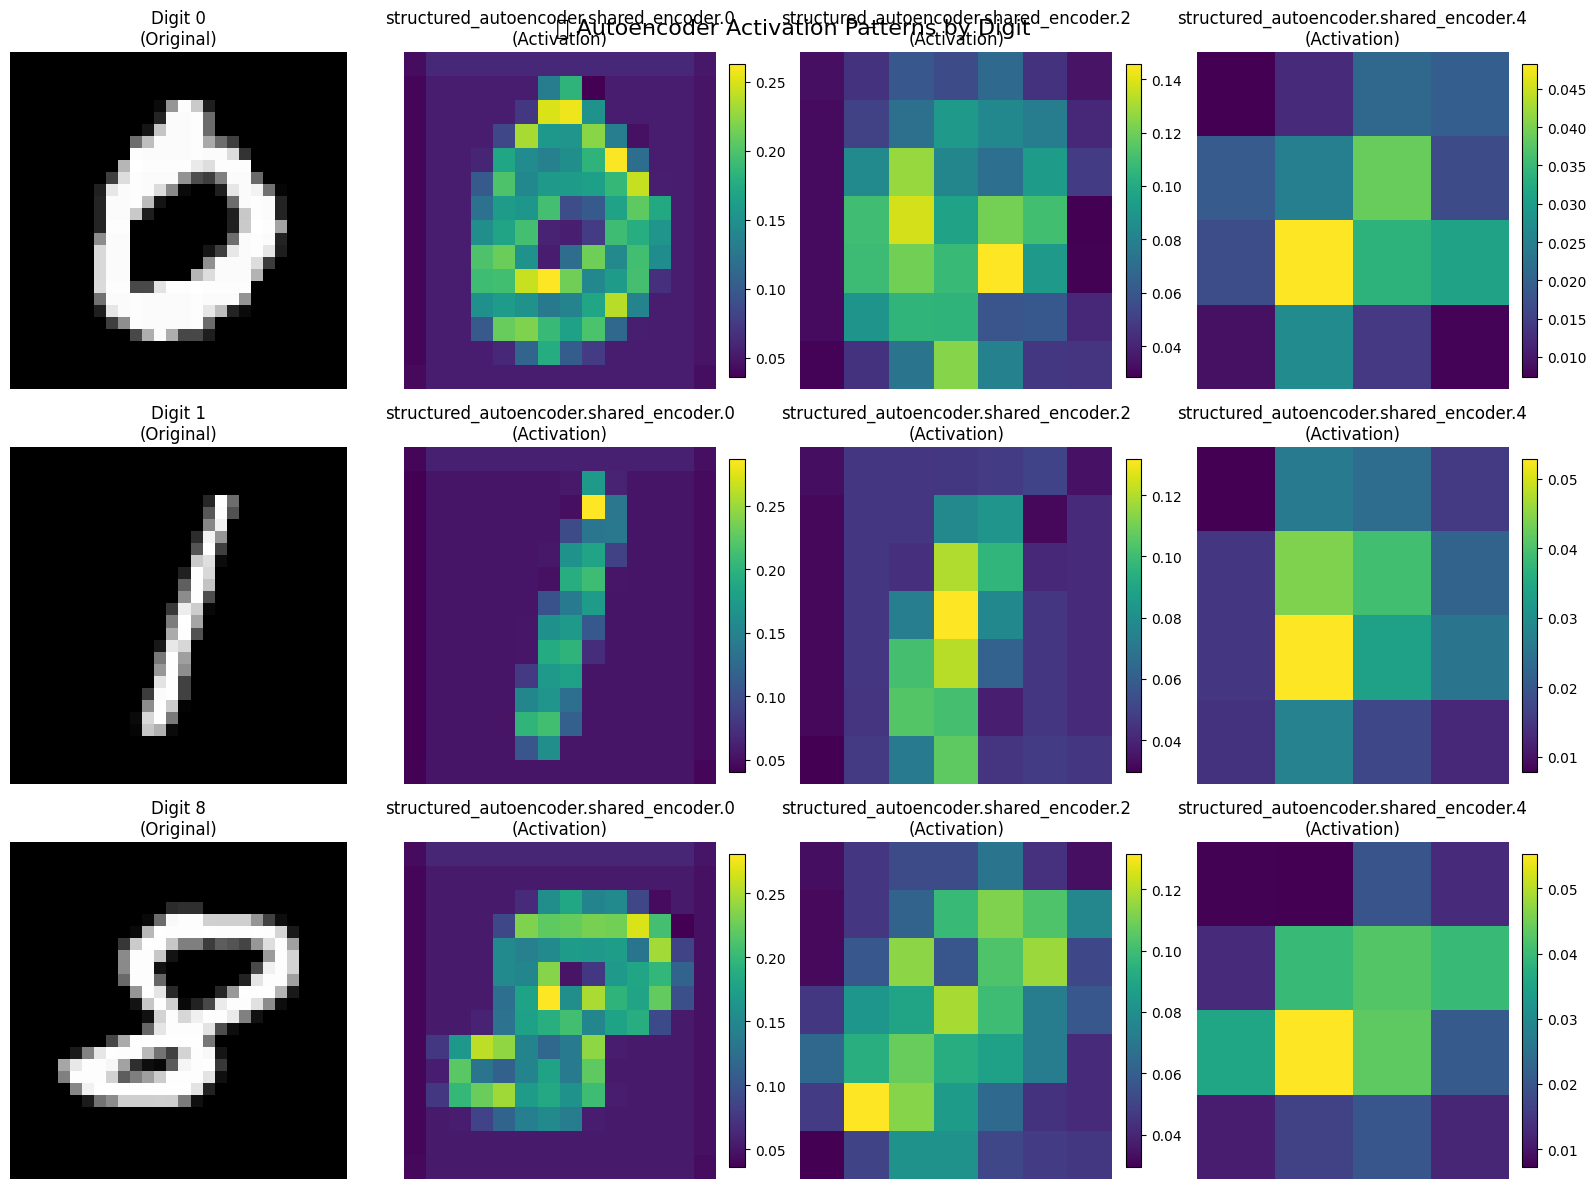


🎯 Comparing latent space representations...


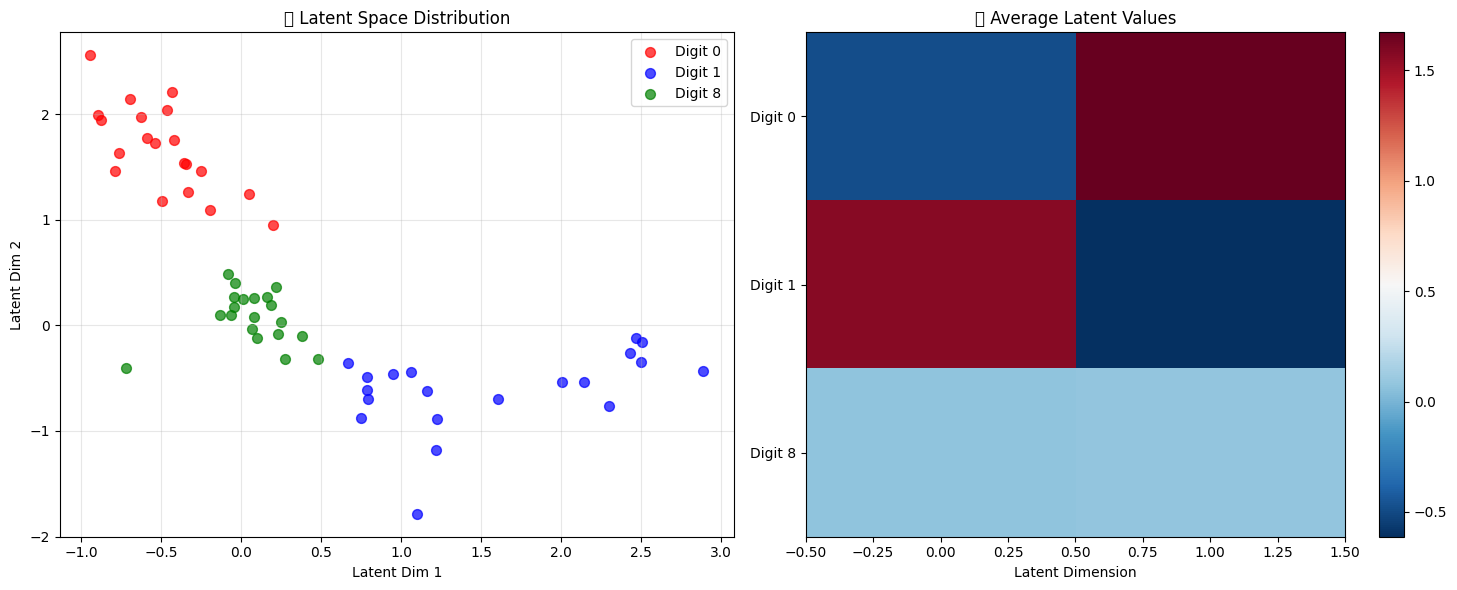


📊 LATENT ANALYSIS:
   Digit 0: Avg magnitude 1.092 ± 0.671
   Digit 1: Avg magnitude 1.090 ± 0.750
   Digit 8: Avg magnitude 0.200 ± 0.154


In [14]:
# 🔥 ACTIVATION HEATMAP VISUALIZATION
# Visualize how the autoencoder internally processes specific digits (0, 1, 8, etc.)

def get_activation_maps(model, input_image):
    """Extract activation maps from different layers of the autoencoder"""
    activation_maps = {}
    
    def hook_fn(name):
        def hook(module, input, output):
            if isinstance(output, torch.Tensor):
                activation_maps[name] = output.detach()
        return hook
    
    # Register hooks on accessible layers
    hooks = []
    layer_names = []
    
    # Try to find and hook layers in the model
    try:
        # Method 1: Hook named modules
        for name, module in model.named_modules():
            if hasattr(module, 'weight') and len(list(module.parameters())) > 0:
                # Skip if it's a parent module containing other modules
                if len(list(module.children())) == 0:
                    layer_names.append(name)
                    hooks.append(module.register_forward_hook(hook_fn(name)))
                    
                    # Limit to first 6 layers for visualization
                    if len(layer_names) >= 6:
                        break
    except:
        # Method 2: Hook direct children if named_modules fails
        for i, module in enumerate(model.children()):
            if hasattr(module, 'weight'):
                name = f'layer_{i}'
                layer_names.append(name)
                hooks.append(module.register_forward_hook(hook_fn(name)))
                
                if len(layer_names) >= 6:
                    break
    
    # Forward pass to collect activations
    model.eval()
    with torch.no_grad():
        _ = model(input_image)
    
    # Remove hooks
    for hook in hooks:
        hook.remove()
    
    return activation_maps, layer_names

def analyze_model_structure(model):
    """Analyze and print the model structure for debugging"""
    print("🔍 Model Structure Analysis:")
    print(f"   Model type: {type(model).__name__}")
    
    # Check for common attributes
    common_attrs = ['encoder', 'decoder', 'fc_mu', 'fc_logvar', 'content_encoder', 'transform_encoder']
    found_attrs = []
    
    for attr in common_attrs:
        if hasattr(model, attr):
            found_attrs.append(attr)
    
    print(f"   Found attributes: {found_attrs}")
    
    # List all named modules
    print("   Named modules:")
    for i, (name, module) in enumerate(model.named_modules()):
        if i < 10 and hasattr(module, 'weight'):  # Show first 10 layers with weights
            print(f"      {name}: {type(module).__name__}")
    
    return found_attrs

def visualize_digit_activations(model, test_loader, device, target_digits=[0, 1, 8]):
    """Create activation heatmaps for specific digits"""
    
    # First, analyze the model structure
    print("🔍 Analyzing model structure...")
    found_attrs = analyze_model_structure(model)
    
    # Find examples of target digits
    digit_examples = {}
    
    for images, labels in test_loader:
        for digit in target_digits:
            if digit not in digit_examples:
                mask = labels == digit
                if mask.any():
                    digit_examples[digit] = images[mask][0:1]  # Take first example
        
        # Break when we have all digits
        if len(digit_examples) == len(target_digits):
            break
    
    if len(digit_examples) == 0:
        print("❌ No target digits found in test data")
        return
    
    print(f"✅ Found examples for digits: {list(digit_examples.keys())}")
    
    # Get activation maps for the first digit to see what we can extract
    first_digit = list(digit_examples.keys())[0]
    first_image = digit_examples[first_digit].to(device)
    
    try:
        activations, layer_names = get_activation_maps(model, first_image)
        print(f"✅ Successfully extracted activations from {len(layer_names)} layers")
        
        if len(activations) == 0:
            print("⚠️ No activations captured. Using alternative approach...")
            visualize_model_outputs(model, digit_examples, device, target_digits)
            return
            
    except Exception as e:
        print(f"⚠️ Activation extraction failed: {e}")
        print("Using alternative visualization approach...")
        visualize_model_outputs(model, digit_examples, device, target_digits)
        return
    
    # Create figure for activation heatmaps
    n_digits = len(digit_examples)
    n_layers = min(3, len(layer_names))  # Show up to 3 layers
    n_cols = n_layers + 1  # +1 for original image
    
    fig = plt.figure(figsize=(4 * n_cols, 4 * n_digits))
    
    for idx, (digit, image) in enumerate(digit_examples.items()):
        image = image.to(device)
        
        # Get activation maps
        activations, _ = get_activation_maps(model, image)
        
        # Original image
        plt.subplot(n_digits, n_cols, idx * n_cols + 1)
        plt.imshow(image[0, 0].cpu().numpy(), cmap='gray')
        plt.title(f'Digit {digit}\n(Original)')
        plt.axis('off')
        
        # Activation maps for selected layers
        selected_layers = layer_names[:n_layers]
        
        for layer_idx, layer_name in enumerate(selected_layers):
            plt.subplot(n_digits, n_cols, idx * n_cols + layer_idx + 2)
            
            if layer_name in activations:
                activation = activations[layer_name]
                
                # Handle batch dimension
                if len(activation.shape) >= 2:
                    activation = activation[0]  # First sample in batch
                
                # Create heatmap based on activation shape
                if len(activation.shape) == 3:  # Conv layer (C, H, W)
                    # Average across channels
                    heatmap = activation.mean(dim=0).cpu().numpy()
                elif len(activation.shape) == 2:  # Matrix
                    heatmap = activation.cpu().numpy()
                elif len(activation.shape) == 1:  # Vector - reshape to square
                    feat_size = len(activation)
                    side = int(np.sqrt(feat_size))
                    if side * side <= feat_size:
                        heatmap = activation[:side*side].reshape(side, side).cpu().numpy()
                    else:
                        # Fallback to 1D visualization
                        heatmap = activation.unsqueeze(0).cpu().numpy()
                else:
                    heatmap = activation.cpu().numpy()
                
                # Plot heatmap
                im = plt.imshow(heatmap, cmap='viridis', aspect='auto')
                plt.title(f'{layer_name}\n(Activation)')
                plt.axis('off')
                
                # Add colorbar
                plt.colorbar(im, fraction=0.046, pad=0.04)
            else:
                plt.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=plt.gca().transAxes)
                plt.title(f'{layer_name}\n(No Data)')
                plt.axis('off')
    
    plt.tight_layout()
    plt.suptitle('🔥 Autoencoder Activation Patterns by Digit', fontsize=16, y=0.98)
    plt.show()

def visualize_model_outputs(model, digit_examples, device, target_digits):
    """Alternative visualization using model outputs directly"""
    print("🎨 Creating model output visualization...")
    
    fig, axes = plt.subplots(len(target_digits), 4, figsize=(16, 4 * len(target_digits)))
    if len(target_digits) == 1:
        axes = axes.reshape(1, -1)
    
    model.eval()
    with torch.no_grad():
        for idx, (digit, image) in enumerate(digit_examples.items()):
            image = image.to(device)
            
            # Get model outputs
            outputs = model(image)
            
            # Original image
            axes[idx, 0].imshow(image[0, 0].cpu().numpy(), cmap='gray')
            axes[idx, 0].set_title(f'Digit {digit}\n(Original)')
            axes[idx, 0].axis('off')
            
            # Show different outputs if available
            if isinstance(outputs, (list, tuple)) and len(outputs) > 0:
                # Reconstruction (usually first output)
                if len(outputs) > 0 and outputs[0] is not None:
                    recon = outputs[0][0, 0].cpu().numpy()
                    axes[idx, 1].imshow(recon, cmap='gray')
                    axes[idx, 1].set_title('Reconstruction')
                    axes[idx, 1].axis('off')
                
                # Content latents (if available)
                if len(outputs) > 1 and outputs[1] is not None:
                    content_latents = outputs[1][0].cpu().numpy()
                    axes[idx, 2].bar(range(len(content_latents)), content_latents)
                    axes[idx, 2].set_title('Content Latents')
                    axes[idx, 2].set_xlabel('Dimension')
                
                # Transform latents (if available)
                if len(outputs) > 2 and outputs[2] is not None:
                    transform_latents = outputs[2][0].cpu().numpy()
                    axes[idx, 3].bar(range(len(transform_latents)), transform_latents)
                    axes[idx, 3].set_title('Transform Latents')
                    axes[idx, 3].set_xlabel('Dimension')
                else:
                    axes[idx, 3].text(0.5, 0.5, 'No Transform\nLatents', ha='center', va='center')
                    axes[idx, 3].set_title('Transform Latents')
            else:
                # Fallback if outputs are not in expected format
                for col in range(1, 4):
                    axes[idx, col].text(0.5, 0.5, 'No Data', ha='center', va='center')
                    axes[idx, col].axis('off')
    
    plt.tight_layout()
    plt.suptitle('🎨 Model Outputs by Digit', fontsize=16, y=0.98)
    plt.show()

def compare_latent_representations(model, test_loader, device, target_digits=[0, 1, 8]):
    """Compare latent space representations of different digits"""
    
    # Collect latent representations
    digit_latents = {digit: [] for digit in target_digits}
    
    model.eval()
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            
            # Get latent representations
            try:
                outputs = model(images)
                
                # Extract content latents (try different indices)
                content_latents = None
                if isinstance(outputs, (list, tuple)):
                    for i, output in enumerate(outputs):
                        if output is not None and len(output.shape) == 2:
                            # Found a 2D tensor that could be latents
                            if output.shape[1] <= 10:  # Reasonable latent dimension
                                content_latents = output
                                break
                
                if content_latents is None:
                    print("⚠️ Could not extract content latents from model outputs")
                    return {}
                
                # Group by digit
                for digit in target_digits:
                    mask = labels == digit
                    if mask.any():
                        digit_latents[digit].extend(content_latents[mask].cpu().numpy())
                
                # Stop when we have enough samples
                if all(len(digit_latents[d]) >= 20 for d in target_digits):
                    break
                    
            except Exception as e:
                print(f"⚠️ Error extracting latents: {e}")
                return {}
    
    # Convert to arrays
    for digit in target_digits:
        if digit_latents[digit]:
            digit_latents[digit] = np.array(digit_latents[digit][:20])  # Take first 20
    
    # Plot latent space analysis
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    # Scatter plot in latent space (assuming at least 2D latents)
    for i, digit in enumerate(target_digits):
        if len(digit_latents[digit]) > 0:
            latents = digit_latents[digit]
            if latents.shape[1] >= 2:
                ax1.scatter(latents[:, 0], latents[:, 1], 
                           c=colors[i], label=f'Digit {digit}', alpha=0.7, s=50)
    
    ax1.set_xlabel('Latent Dim 1')
    ax1.set_ylabel('Latent Dim 2')
    ax1.set_title('🎯 Latent Space Distribution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Heatmap of average latent values
    latent_matrix = []
    digit_labels = []
    
    for digit in target_digits:
        if len(digit_latents[digit]) > 0:
            avg_latent = np.mean(digit_latents[digit], axis=0)
            latent_matrix.append(avg_latent)
            digit_labels.append(f'Digit {digit}')
    
    if latent_matrix:
        latent_matrix = np.array(latent_matrix)
        im = ax2.imshow(latent_matrix, cmap='RdBu_r', aspect='auto')
        ax2.set_yticks(range(len(digit_labels)))
        ax2.set_yticklabels(digit_labels)
        ax2.set_xlabel('Latent Dimension')
        ax2.set_title('🌡️ Average Latent Values')
        plt.colorbar(im, ax=ax2)
    
    plt.tight_layout()
    plt.show()
    
    return digit_latents

if model_loaded:
    print("🔥 Creating activation visualizations for digits 0, 1, and 8...")
    print("This shows how your autoencoder internally processes different digit shapes.\n")
    
    # Create activation heatmaps
    visualize_digit_activations(model, test_loader, device, target_digits=[0, 1, 8])
    
    print("\n🎯 Comparing latent space representations...")
    digit_latents = compare_latent_representations(model, test_loader, device, target_digits=[0, 1, 8])
    
    # Print analysis
    if digit_latents:
        print("\n📊 LATENT ANALYSIS:")
        for digit, latents in digit_latents.items():
            if len(latents) > 0:
                avg_magnitude = np.mean(np.abs(latents))
                std_magnitude = np.std(np.abs(latents))
                print(f"   Digit {digit}: Avg magnitude {avg_magnitude:.3f} ± {std_magnitude:.3f}")
    
else:
    print("❌ Cannot create activation visualizations without loaded model.")

🌊 Starting COMPLETE tensor flow visualization...
This will show the FULL autoencoder journey: Input → Encoder → Latent → Decoder → Output

🌊 Creating COMPLETE end-to-end tensor flow visualization...
This shows the FULL autoencoder journey: Input → Encoder → Latent → Decoder → Reconstruction

🔍 Processing COMPLETE flow for Digit 0...
🌊 Capturing COMPLETE tensor flow: Encoder → Latent → Decoder → Output...
✅ Captured 20 layer outputs from COMPLETE network
🎨 Plotting complete flow: 21 layers for digit 0

🔍 Processing COMPLETE flow for Digit 0...
🌊 Capturing COMPLETE tensor flow: Encoder → Latent → Decoder → Output...
✅ Captured 20 layer outputs from COMPLETE network
🎨 Plotting complete flow: 21 layers for digit 0


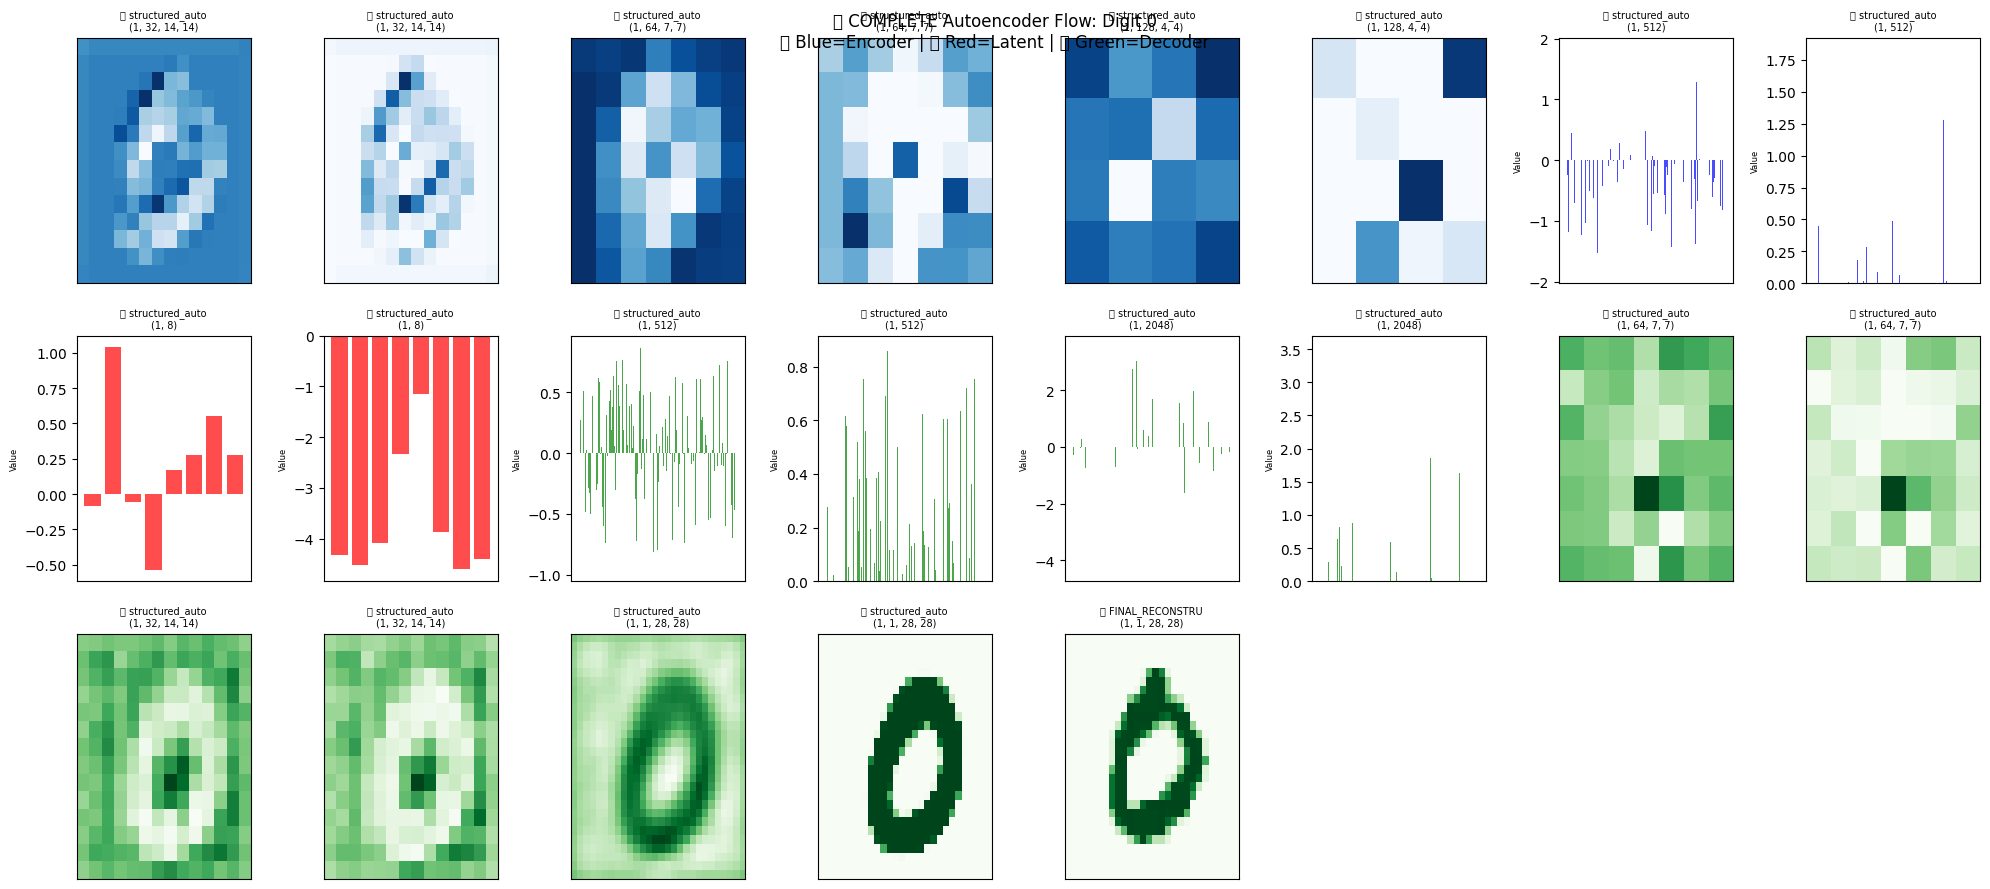


📊 COMPLETE TENSOR STATISTICS for Digit 0:

🔸 ENCODER PHASE:
    0. structured_autoencoder.sh... | (32, 14, 14) | Mean:  -0.184 | Std:   0.592 | Range: [ -3.787,   2.961]
    1. structured_autoencoder.sh... | (32, 14, 14) | Mean:   0.097 | Std:   0.276 | Range: [  0.000,   2.961]
    2. structured_autoencoder.sh... | (64, 7, 7) | Mean:  -0.489 | Std:   0.892 | Range: [ -5.754,   2.646]
    3. structured_autoencoder.sh... | (64, 7, 7) | Mean:   0.072 | Std:   0.260 | Range: [  0.000,   2.646]
    4. structured_autoencoder.sh... | (128, 4, 4) | Mean:  -0.512 | Std:   0.528 | Range: [ -3.609,   1.499]
    5. structured_autoencoder.sh... | (128, 4, 4) | Mean:   0.022 | Std:   0.117 | Range: [  0.000,   1.499]
    6. structured_autoencoder.sh... | (512,) | Mean:  -0.082 | Std:   0.429 | Range: [ -1.844,   1.831]
    7. structured_autoencoder.sh... | (512,) | Mean:   0.065 | Std:   0.247 | Range: [  0.000,   1.831]

🔸 LATENT PHASE:
    8. structured_autoencoder.la... | (8,) | Mean:   0.204 |

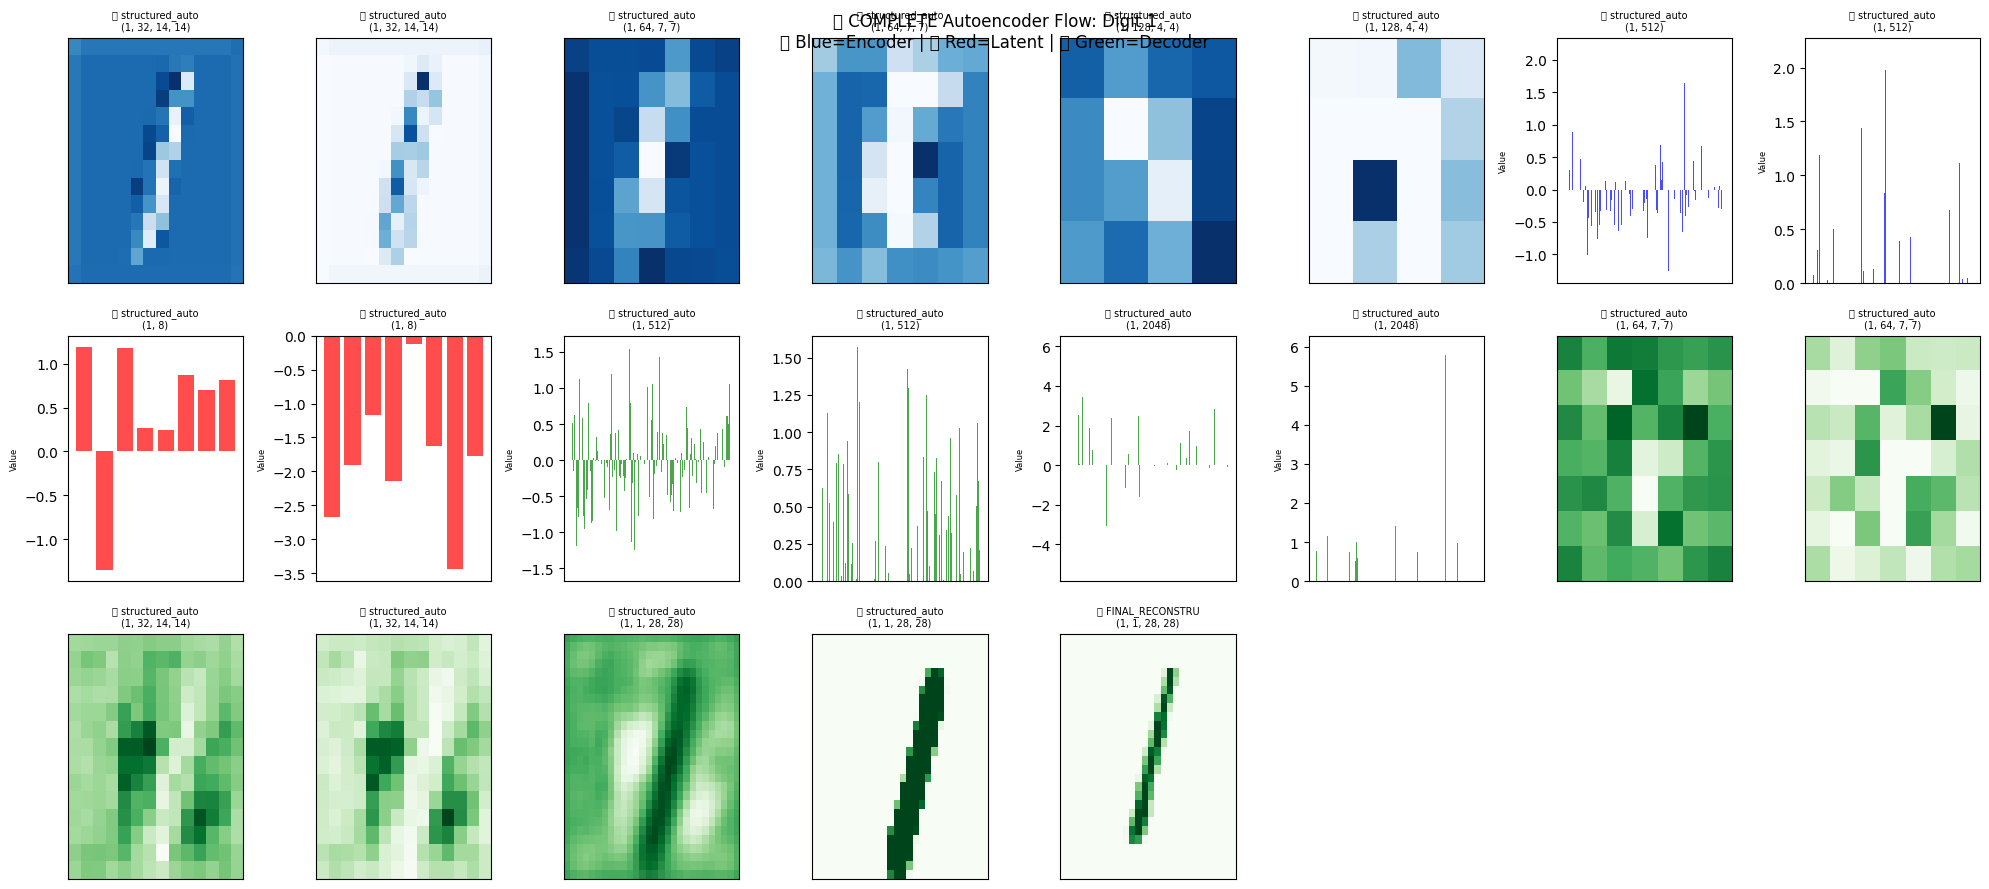


📊 COMPLETE TENSOR STATISTICS for Digit 1:

🔸 ENCODER PHASE:
    0. structured_autoencoder.sh... | (32, 14, 14) | Mean:  -0.088 | Std:   0.365 | Range: [ -3.128,   1.937]
    1. structured_autoencoder.sh... | (32, 14, 14) | Mean:   0.069 | Std:   0.192 | Range: [  0.000,   1.937]
    2. structured_autoencoder.sh... | (64, 7, 7) | Mean:  -0.325 | Std:   0.579 | Range: [ -3.429,   2.096]
    3. structured_autoencoder.sh... | (64, 7, 7) | Mean:   0.057 | Std:   0.211 | Range: [  0.000,   2.096]
    4. structured_autoencoder.sh... | (128, 4, 4) | Mean:  -0.339 | Std:   0.388 | Range: [ -2.485,   1.908]
    5. structured_autoencoder.sh... | (128, 4, 4) | Mean:   0.025 | Std:   0.120 | Range: [  0.000,   1.908]
    6. structured_autoencoder.sh... | (512,) | Mean:  -0.016 | Std:   0.363 | Range: [ -1.274,   2.167]
    7. structured_autoencoder.sh... | (512,) | Mean:   0.076 | Std:   0.279 | Range: [  0.000,   2.167]

🔸 LATENT PHASE:
    8. structured_autoencoder.la... | (8,) | Mean:   0.489 |

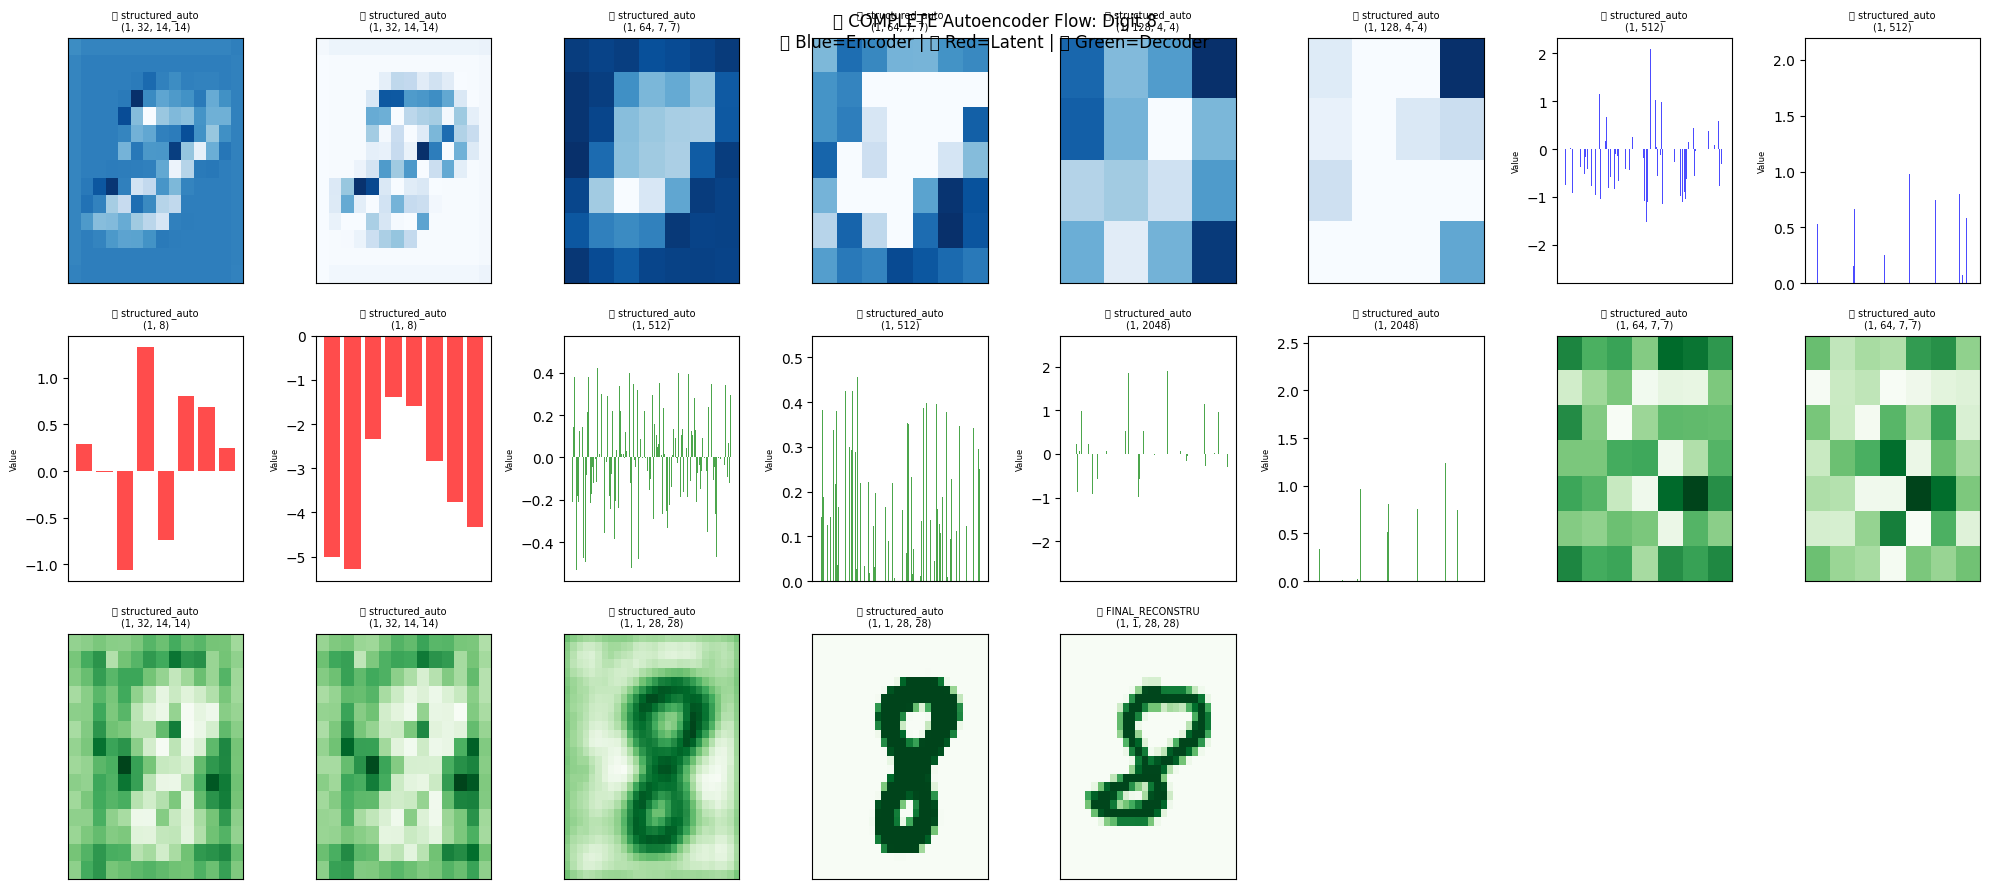


📊 COMPLETE TENSOR STATISTICS for Digit 8:

🔸 ENCODER PHASE:
    0. structured_autoencoder.sh... | (32, 14, 14) | Mean:  -0.167 | Std:   0.566 | Range: [ -3.866,   2.616]
    1. structured_autoencoder.sh... | (32, 14, 14) | Mean:   0.097 | Std:   0.260 | Range: [  0.000,   2.616]
    2. structured_autoencoder.sh... | (64, 7, 7) | Mean:  -0.457 | Std:   0.843 | Range: [ -4.799,   2.554]
    3. structured_autoencoder.sh... | (64, 7, 7) | Mean:   0.070 | Std:   0.243 | Range: [  0.000,   2.554]
    4. structured_autoencoder.sh... | (128, 4, 4) | Mean:  -0.453 | Std:   0.474 | Range: [ -2.944,   2.065]
    5. structured_autoencoder.sh... | (128, 4, 4) | Mean:   0.025 | Std:   0.128 | Range: [  0.000,   2.065]
    6. structured_autoencoder.sh... | (512,) | Mean:  -0.112 | Std:   0.505 | Range: [ -2.574,   2.091]
    7. structured_autoencoder.sh... | (512,) | Mean:   0.067 | Std:   0.260 | Range: [  0.000,   2.091]

🔸 LATENT PHASE:
    8. structured_autoencoder.la... | (8,) | Mean:   0.196 |

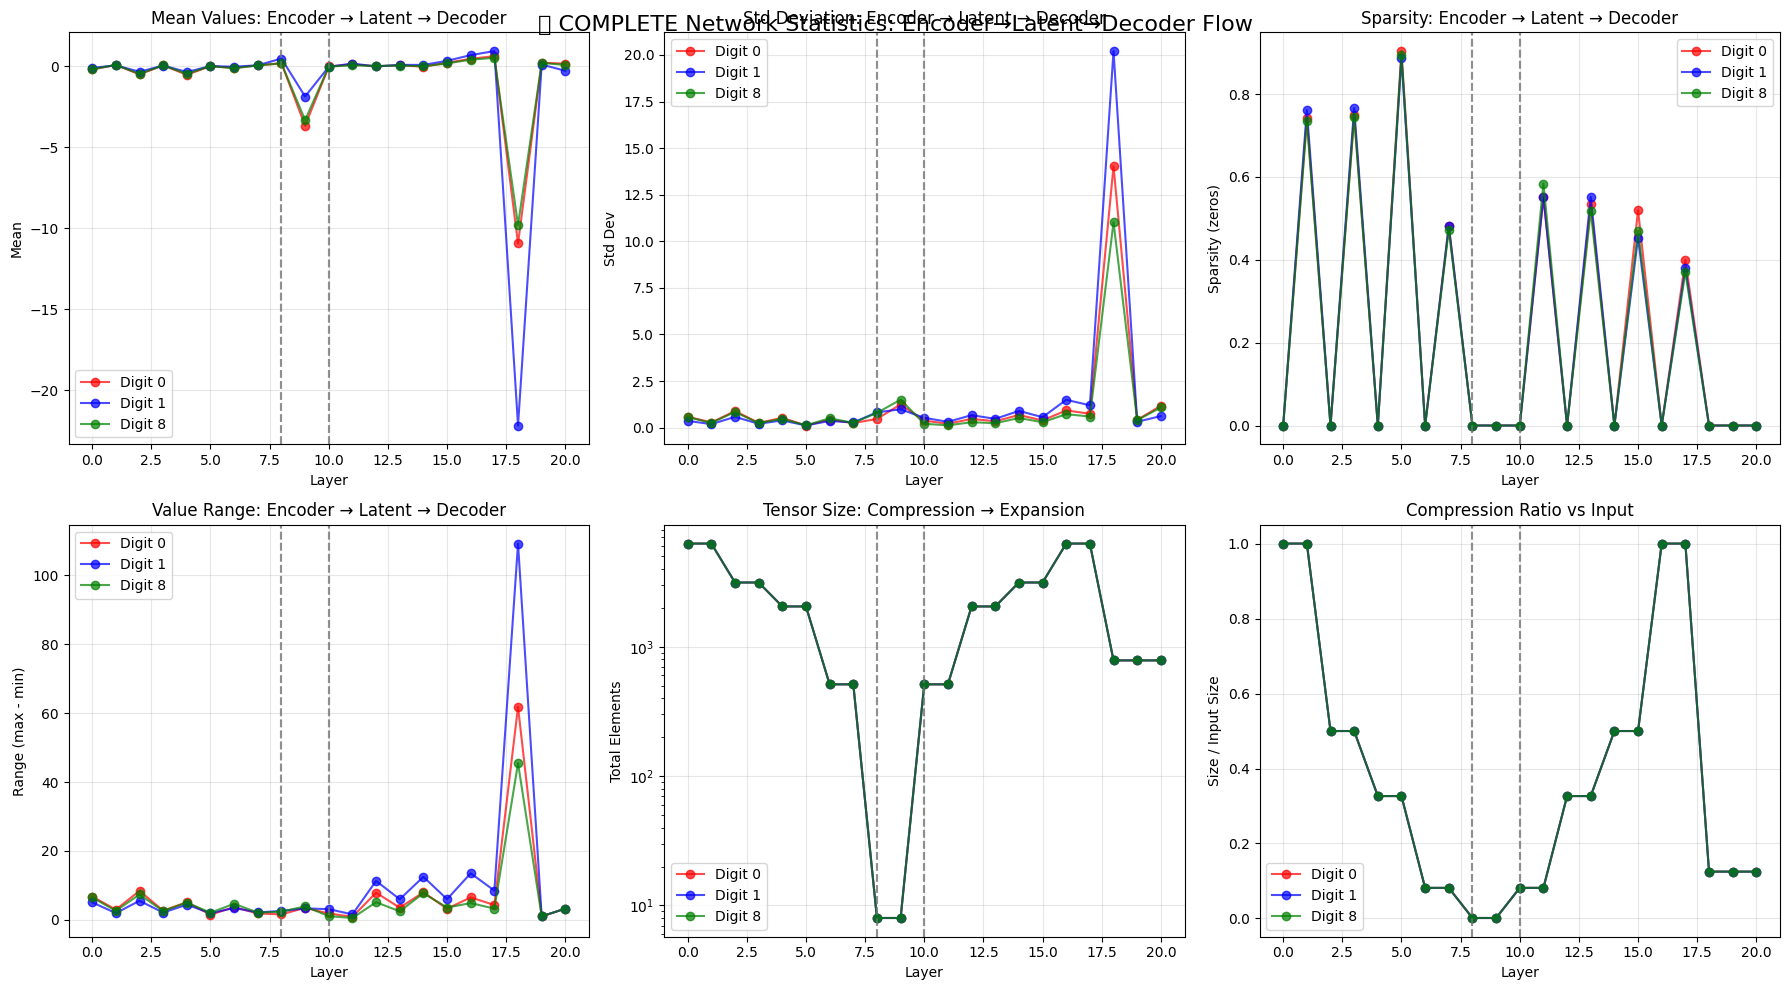


🎉 COMPLETE tensor flow visualization finished!
You can now see:
   🔹 FULL encoder-decoder flow with all layers
   🔹 Phase-coded visualization (Blue=Encoder, Red=Latent, Green=Decoder)
   🔹 Complete statistical evolution through the entire network
   🔹 Compression and reconstruction patterns
   🔹 Final reconstructed digit outputs


In [16]:
# 🌊 COMPLETE TENSOR FLOW VISUALIZATION
# Visualize the actual flow of values through the ENTIRE network: Encoder → Latent → Decoder → Output

def visualize_complete_tensor_flow(model, input_image, capture_all_layers=True):
    """
    Visualize how tensors transform through the COMPLETE network including decoder
    """
    print("🌊 Capturing COMPLETE tensor flow: Encoder → Latent → Decoder → Output...")
    
    # Store intermediate tensors in execution order
    layer_outputs = []
    layer_names = []
    layer_shapes = []
    execution_order = []
    
    def capture_hook(name):
        def hook(module, input, output):
            if isinstance(output, torch.Tensor):
                # Store a copy with execution order tracking
                layer_outputs.append(output.detach().clone())
                layer_names.append(name)
                layer_shapes.append(tuple(output.shape))
                execution_order.append(len(layer_outputs) - 1)
        return hook
    
    # Register hooks on ALL computation layers (no limits)
    hooks = []
    
    for name, module in model.named_modules():
        # Hook ALL computation layers including activations
        if (hasattr(module, 'weight') or 
            isinstance(module, (torch.nn.ReLU, torch.nn.Sigmoid, torch.nn.Tanh, 
                              torch.nn.LeakyReLU, torch.nn.ELU, torch.nn.GELU,
                              torch.nn.Dropout, torch.nn.BatchNorm1d, torch.nn.BatchNorm2d))):
            if len(list(module.children())) == 0:  # Leaf module
                hooks.append(module.register_forward_hook(capture_hook(name)))
    
    # Forward pass to capture ALL intermediate outputs
    model.eval()
    with torch.no_grad():
        final_output = model(input_image)
    
    # Remove hooks
    for hook in hooks:
        hook.remove()
    
    print(f"✅ Captured {len(layer_outputs)} layer outputs from COMPLETE network")
    
    # Add final output explicitly if it's not already captured
    if isinstance(final_output, (list, tuple)):
        if len(final_output) > 0:
            layer_outputs.append(final_output[0].detach().clone())  # Reconstruction
            layer_names.append('FINAL_RECONSTRUCTION')
            layer_shapes.append(tuple(final_output[0].shape))
    else:
        layer_outputs.append(final_output.detach().clone())
        layer_names.append('FINAL_OUTPUT')
        layer_shapes.append(tuple(final_output.shape))
    
    return layer_outputs, layer_names, layer_shapes, final_output

def plot_complete_tensor_flow_sequence(layer_outputs, layer_names, layer_shapes, digit_label):
    """
    Create a comprehensive visualization showing the COMPLETE autoencoder flow
    """
    n_layers = len(layer_outputs)
    if n_layers == 0:
        print("❌ No layer outputs captured")
        return
    
    print(f"🎨 Plotting complete flow: {n_layers} layers for digit {digit_label}")
    
    # Calculate grid layout - use more columns for better flow visualization
    cols = min(8, n_layers)
    rows = (n_layers + cols - 1) // cols
    
    fig = plt.figure(figsize=(2.5 * cols, 3 * rows))
    
    # Track where we are in the network
    encoder_phase = True
    latent_phase = False
    decoder_phase = False
    
    for i, (output, name, shape) in enumerate(zip(layer_outputs, layer_names, layer_shapes)):
        plt.subplot(rows, cols, i + 1)
        
        # Determine network phase based on tensor shapes and names
        if 'latent' in name.lower() or 'mu' in name.lower() or 'logvar' in name.lower():
            latent_phase = True
            encoder_phase = False
        elif 'decode' in name.lower() or 'reconstruction' in name.lower() or i > len(layer_outputs) * 0.6:
            decoder_phase = True
            latent_phase = False
        
        # Handle different tensor shapes for visualization
        tensor = output[0]  # First sample in batch
        
        # Color scheme based on network phase
        if encoder_phase:
            cmap = 'Blues'
            phase_emoji = '📥'
        elif latent_phase:
            cmap = 'Reds'
            phase_emoji = '🎯'
        elif decoder_phase:
            cmap = 'Greens'
            phase_emoji = '📤'
        else:
            cmap = 'viridis'
            phase_emoji = '🔄'
        
        if len(tensor.shape) == 3:  # Conv output (C, H, W)
            # Show average across channels or first few channels
            if tensor.shape[0] == 1:
                heatmap = tensor[0].cpu().numpy()
            else:
                # Average across first few channels
                n_channels = min(4, tensor.shape[0])
                heatmap = tensor[:n_channels].mean(dim=0).cpu().numpy()
            
            plt.imshow(heatmap, cmap=cmap, aspect='auto')
            plt.title(f'{phase_emoji} {name[:15]}\n{shape}', fontsize=7)
            
        elif len(tensor.shape) == 2:  # Matrix (e.g., after flatten or linear layer)
            if tensor.shape[1] > 100:
                # Large feature vector - show as line plot
                plt.plot(tensor[0].cpu().numpy(), color='blue' if encoder_phase else 'red' if latent_phase else 'green')
                plt.title(f'{phase_emoji} {name[:15]}\n{shape}', fontsize=7)
                plt.ylabel('Value', fontsize=6)
            else:
                # Small matrix - show as heatmap
                heatmap = tensor.cpu().numpy()
                plt.imshow(heatmap, cmap=cmap, aspect='auto')
                plt.title(f'{phase_emoji} {name[:15]}\n{shape}', fontsize=7)
                
        elif len(tensor.shape) == 1:  # Vector (e.g., latent representation)
            values = tensor.cpu().numpy()
            color = 'blue' if encoder_phase else 'red' if latent_phase else 'green'
            plt.bar(range(len(values)), values, alpha=0.7, color=color)
            plt.title(f'{phase_emoji} {name[:15]}\n{shape}', fontsize=7)
            plt.ylabel('Value', fontsize=6)
            
        else:  # Other shapes - show as histogram
            values = tensor.flatten().cpu().numpy()
            color = 'blue' if encoder_phase else 'red' if latent_phase else 'green'
            plt.hist(values, bins=15, alpha=0.7, color=color)
            plt.title(f'{phase_emoji} {name[:15]}\n{shape}', fontsize=7)
            plt.ylabel('Count', fontsize=6)
        
        plt.xticks([])
        if len(tensor.shape) >= 2:
            plt.yticks([])
    
    plt.tight_layout()
    plt.suptitle(f'🌊 COMPLETE Autoencoder Flow: Digit {digit_label}\n📥 Blue=Encoder | 🎯 Red=Latent | 📤 Green=Decoder', 
                 fontsize=12, y=0.98)
    plt.show()

def analyze_complete_tensor_statistics(layer_outputs, layer_names, digit_label):
    """
    Analyze statistical properties through the COMPLETE network
    """
    print(f"\n📊 COMPLETE TENSOR STATISTICS for Digit {digit_label}:")
    print("=" * 80)
    
    stats_data = []
    
    # Determine phases
    phases = []
    for i, name in enumerate(layer_names):
        if 'latent' in name.lower() or 'mu' in name.lower() or 'logvar' in name.lower():
            phase = 'LATENT'
        elif 'decode' in name.lower() or 'reconstruction' in name.lower() or i > len(layer_names) * 0.6:
            phase = 'DECODER'
        else:
            phase = 'ENCODER'
        phases.append(phase)
    
    current_phase = None
    for i, (output, name, phase) in enumerate(zip(layer_outputs, layer_names, phases)):
        # Print phase headers
        if phase != current_phase:
            print(f"\n🔸 {phase} PHASE:")
            current_phase = phase
        
        tensor = output[0]  # First sample
        
        # Calculate statistics
        mean_val = tensor.mean().item()
        std_val = tensor.std().item()
        min_val = tensor.min().item()
        max_val = tensor.max().item()
        sparsity = (tensor == 0).float().mean().item()
        
        stats_data.append({
            'layer': i,
            'name': name,
            'phase': phase,
            'mean': mean_val,
            'std': std_val,
            'min': min_val,
            'max': max_val,
            'sparsity': sparsity,
            'shape': tuple(tensor.shape)
        })
        
        # Truncate long names for display
        display_name = name[:25] + "..." if len(name) > 25 else name
        print(f"   {i:2d}. {display_name:28s} | {tuple(tensor.shape)} | Mean: {mean_val:7.3f} | Std: {std_val:7.3f} | Range: [{min_val:7.3f}, {max_val:7.3f}]")
    
    return stats_data

def plot_complete_statistics_evolution(all_stats, target_digits):
    """
    Plot statistics evolution through the COMPLETE network showing encoder/decoder phases
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    for digit_idx, (digit, stats_data) in enumerate(all_stats.items()):
        if len(stats_data) == 0:
            continue
            
        layers = [s['layer'] for s in stats_data]
        means = [s['mean'] for s in stats_data]
        stds = [s['std'] for s in stats_data]
        sparsities = [s['sparsity'] for s in stats_data]
        ranges = [s['max'] - s['min'] for s in stats_data]
        phases = [s['phase'] for s in stats_data]
        
        color = colors[digit_idx % len(colors)]
        
        # Mark phase transitions
        encoder_end = next((i for i, p in enumerate(phases) if p != 'ENCODER'), len(phases))
        latent_end = next((i for i, p in enumerate(phases) if p == 'DECODER'), len(phases))
        
        # Mean evolution
        axes[0, 0].plot(layers, means, 'o-', color=color, label=f'Digit {digit}', alpha=0.7)
        axes[0, 0].axvline(x=encoder_end, color='gray', linestyle='--', alpha=0.5)
        axes[0, 0].axvline(x=latent_end, color='gray', linestyle='--', alpha=0.5)
        axes[0, 0].set_title('Mean Values: Encoder → Latent → Decoder')
        axes[0, 0].set_xlabel('Layer')
        axes[0, 0].set_ylabel('Mean')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Standard deviation evolution
        axes[0, 1].plot(layers, stds, 'o-', color=color, label=f'Digit {digit}', alpha=0.7)
        axes[0, 1].axvline(x=encoder_end, color='gray', linestyle='--', alpha=0.5)
        axes[0, 1].axvline(x=latent_end, color='gray', linestyle='--', alpha=0.5)
        axes[0, 1].set_title('Std Deviation: Encoder → Latent → Decoder')
        axes[0, 1].set_xlabel('Layer')
        axes[0, 1].set_ylabel('Std Dev')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Sparsity evolution
        axes[0, 2].plot(layers, sparsities, 'o-', color=color, label=f'Digit {digit}', alpha=0.7)
        axes[0, 2].axvline(x=encoder_end, color='gray', linestyle='--', alpha=0.5)
        axes[0, 2].axvline(x=latent_end, color='gray', linestyle='--', alpha=0.5)
        axes[0, 2].set_title('Sparsity: Encoder → Latent → Decoder')
        axes[0, 2].set_xlabel('Layer')
        axes[0, 2].set_ylabel('Sparsity (zeros)')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)
        
        # Value range evolution
        axes[1, 0].plot(layers, ranges, 'o-', color=color, label=f'Digit {digit}', alpha=0.7)
        axes[1, 0].axvline(x=encoder_end, color='gray', linestyle='--', alpha=0.5)
        axes[1, 0].axvline(x=latent_end, color='gray', linestyle='--', alpha=0.5)
        axes[1, 0].set_title('Value Range: Encoder → Latent → Decoder')
        axes[1, 0].set_xlabel('Layer')
        axes[1, 0].set_ylabel('Range (max - min)')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Tensor size evolution
        sizes = [np.prod(s['shape']) for s in stats_data]
        axes[1, 1].plot(layers, sizes, 'o-', color=color, label=f'Digit {digit}', alpha=0.7)
        axes[1, 1].axvline(x=encoder_end, color='gray', linestyle='--', alpha=0.5)
        axes[1, 1].axvline(x=latent_end, color='gray', linestyle='--', alpha=0.5)
        axes[1, 1].set_title('Tensor Size: Compression → Expansion')
        axes[1, 1].set_xlabel('Layer')
        axes[1, 1].set_ylabel('Total Elements')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].set_yscale('log')
        
        # Information flow (relative to input)
        input_size = sizes[0] if sizes else 1
        compression_ratio = [s / input_size for s in sizes]
        axes[1, 2].plot(layers, compression_ratio, 'o-', color=color, label=f'Digit {digit}', alpha=0.7)
        axes[1, 2].axvline(x=encoder_end, color='gray', linestyle='--', alpha=0.5)
        axes[1, 2].axvline(x=latent_end, color='gray', linestyle='--', alpha=0.5)
        axes[1, 2].set_title('Compression Ratio vs Input')
        axes[1, 2].set_xlabel('Layer')
        axes[1, 2].set_ylabel('Size / Input Size')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('📈 COMPLETE Network Statistics: Encoder→Latent→Decoder Flow', fontsize=16, y=0.98)
    plt.show()

def visualize_end_to_end_flow(model, test_loader, device, target_digits=[0, 1, 8]):
    """
    Complete end-to-end tensor flow visualization
    """
    print("🌊 Creating COMPLETE end-to-end tensor flow visualization...")
    print("This shows the FULL autoencoder journey: Input → Encoder → Latent → Decoder → Reconstruction")
    
    # Find examples of target digits
    digit_examples = {}
    
    for images, labels in test_loader:
        for digit in target_digits:
            if digit not in digit_examples:
                mask = labels == digit
                if mask.any():
                    digit_examples[digit] = images[mask][0:1]  # Take first example
        
        if len(digit_examples) == len(target_digits):
            break
    
    if len(digit_examples) == 0:
        print("❌ No target digits found")
        return
    
    all_stats = {}
    
    # Process each digit with complete flow
    for digit, image in digit_examples.items():
        print(f"\n🔍 Processing COMPLETE flow for Digit {digit}...")
        
        image = image.to(device)
        
        # Capture complete tensor flow
        layer_outputs, layer_names, layer_shapes, final_output = visualize_complete_tensor_flow(
            model, image, capture_all_layers=True
        )
        
        if len(layer_outputs) > 0:
            # Plot complete tensor flow sequence
            plot_complete_tensor_flow_sequence(layer_outputs, layer_names, layer_shapes, digit)
            
            # Analyze complete statistics
            stats_data = analyze_complete_tensor_statistics(layer_outputs, layer_names, digit)
            all_stats[digit] = stats_data
        else:
            print(f"⚠️ No layer outputs captured for digit {digit}")
    
    # Plot comparative statistics for complete flow
    if len(all_stats) > 1:
        print("\n📈 Creating complete network statistics visualization...")
        plot_complete_statistics_evolution(all_stats, target_digits)
    
    return all_stats

# Execute the COMPLETE tensor flow visualization
if model_loaded:
    print("🌊 Starting COMPLETE tensor flow visualization...")
    print("This will show the FULL autoencoder journey: Input → Encoder → Latent → Decoder → Output\n")
    
    # Run the complete end-to-end visualization
    complete_tensor_stats = visualize_end_to_end_flow(model, test_loader, device, target_digits=[0, 1, 8])
    
    print("\n🎉 COMPLETE tensor flow visualization finished!")
    print("You can now see:")
    print("   🔹 FULL encoder-decoder flow with all layers")
    print("   🔹 Phase-coded visualization (Blue=Encoder, Red=Latent, Green=Decoder)")
    print("   🔹 Complete statistical evolution through the entire network")
    print("   🔹 Compression and reconstruction patterns")
    print("   🔹 Final reconstructed digit outputs")
    
else:
    print("❌ Cannot create complete tensor flow visualization without loaded model.")